$
\def\D{\Omega}
\def\ipar{m}
\def\R{\mathbb{R}}
\def\del{\partial}
\def\vec{\bf}
\def\priorm{\mu_0}
\def\C{\mathcal{C}}
\def\Acal{\mathcal{A}}
\def\postm{\mu_{\rm{post}}}
\def\iparpost{\ipar_\text{post}}
\def\obs{ {\vec d}} 
\def\yobs{\obs^{\text{obs}}}
\def\obsop{\mathcal{B}}
\def\dd{\vec{\bar{d}}}
\def\iFF{\mathcal{F}}
\def\iFFadj{\mathcal{F}^*}
\def\ncov{\Gamma_{\mathrm{noise}}}
$
# Bayesian initial condition inversion in an advection-diffusion problem 

In this example we tackle the problem of quantifying the uncertainty in the solution of an inverse problem governed by a parabolic PDE via the Bayesian inference framework. The underlying PDE is a time-dependent advection-diffusion equation in which we seek to infer an unknown initial condition from spatio-temporal point measurements.

### The Bayesian inverse problem:

Following the Bayesian framework, we utilize 
a Gaussian prior measure $\priorm = \mathcal{N}(\ipar_0,\C_0)$,
with $\C_0=\Acal^{-2}$ where $\Acal$ is an elliptic differential operator as 
described in the PoissonBayesian example, and use an additive
Gaussian noise model. Therefore, the solution of the Bayesian inverse
problem is the posterior measure, $\postm = \mathcal{N}(\iparpost,\C_\text{post})$ with
$\iparpost$ and $\C_\text{post}$.

- The posterior mean $\iparpost$ is characterized as the minimizer of

$$
\begin{aligned}
& \mathcal{J}(\ipar) :=
  \frac{1}{2} \left\| \obsop u(\ipar) -\obs  \right\|^2_{\ncov^{-1}}
  + \frac 12 \left\| \Acal(\ipar - \ipar_0 \right)\|^2_{L^2(\D)},
\end{aligned}
$$

which can also be interpreted as the regularized functional to be
minimized in deterministic inversion. The observation operator $\mathcal{B}$ extracts the values of the forward solution $u$ on a set of
locations $\{{\vec{x}}_1, \ldots, {\vec{x}}_n\} \subset \D$ at
times $\{t_1, \ldots, t_N\} \subset [0, T]$.

- The posterior covariance $\C_{\text{post}}$ is the inverse of the Hessian of $\mathcal{J}(\ipar)$, i.e.,

$$
\C_{\text{post}} = (\iFFadj \ncov^{-1} \iFF + \C_0^{-1})^{-1}.
$$


### The forward problem:

The parameter-to-observable map $\iFF \,\ipar := \obsop\, u(\ipar)$ maps an initial condition $\ipar \in L^2(\D)$ to pointwise spatiotemporal observations of the concentration field $u({\vec x},t)$ through solution of the advection-diffusion equation given by

$$
\begin{split}
u_t - \kappa\Delta u + {\vec v} \cdot \nabla u &= 0     & \quad \text{in } \D\times(0,T),\\
                                 u(\cdot, 0) &= \ipar & \quad \text{in } \D,\\
                \kappa \nabla u\cdot {\vec{n}} &= 0     & \quad \text{on } \partial\D \times (0,T).
\end{split}
$$

Here, $\D \subset \R^d$ ($d \in \{2, 3\}$) is a bounded domain, $\kappa > 0$ is the diffusion coefficient and $T > 0$ is the final
time. The velocity field
$\vec{v}$ is computed by solving the following steady-state
Navier-Stokes equation with the side walls driving the flow:

$$
\begin{aligned}
- \frac{1}{\operatorname{Re}} \Delta {\vec v} + \nabla q + {\vec v} \cdot \nabla {\vec v} &= 0 &\quad&\text{ in }\D,\\
\nabla \cdot {\vec v} &= 0 &&\text{ in }\D,\\
{\vec v} &= {\vec g} &&\text{ on } \partial\D.
\end{aligned}
$$

Here, $q$ is pressure, $\text{Re}$ is the Reynolds number. The Dirichlet boundary data
${\vec g} \in \R^d$ is given by 
${\vec g} = {\vec e}_2$ on the left wall of the domain, 
${\vec g}=-{\vec e}_2$ on the right wall,  and ${\vec g} = {\vec 0}$ everywhere else.

### The adjoint problem:

The adjoint problem is a final value problem, since $p$ is specified at $t = T$ rather than at $t = 0$. Thus, it is solved backwards in time, which amounts to the solution of the advection-diffusion equation

$$
\begin{aligned}
-p_t - \nabla \cdot (p {\vec v}) - \kappa \Delta p  &= -\obsop^* (\obsop u - \obs) & \quad &\text{ in } \D\times (0,T),\\
                                      p(\cdot, T) &= 0             &       &\text{ in } \D,\\ 
({ \vec{v} }p+\kappa\nabla p)\cdot {\vec{n}}            &= 0             &       &\text{ on } \partial\D\times (0,T).
\end{aligned}
$$

Then, the adjoint of the parameter to observable map $\iFF^*$ is defined by setting $\iFF^*\obs = p({\vec x}, 0).$

## 1. Load modules

In [1]:
import dolfin as dl
#import ufl
import math
import numpy as np
import matplotlib.pyplot as plt
#import scipy.optimize as opt
import nlopt
%matplotlib inline
import sys
import os
sys.path.append( os.environ.get('HIPPYLIB_BASE_DIR', "../") )
sys.path.insert(1, '/mnt/c/Users/Sonia/Documents/Courant/Research/INLA/hippylib')
from hippylib import *
sys.path.append( os.environ.get('HIPPYLIB_BASE_DIR', "..") + "/applications/ad_diff/" )
from model_ad_diff import SpaceTimePointwiseStateObservation
# modified hippylib code (makes kappa no longer hardcoded)
from model_ad_diff_modified import TimeDependentAD
from posterior_modified import *

import logging
logging.getLogger('FFC').setLevel(logging.WARNING)
#logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)

## 2. Construct the velocity field

In [2]:
# All from original AdvectionDiffusionBayesian tutorial
def v_boundary(x,on_boundary):
    return on_boundary

def q_boundary(x,on_boundary):
    return x[0] < dl.DOLFIN_EPS and x[1] < dl.DOLFIN_EPS
        
def computeVelocityField(mesh):
    Xh = dl.VectorFunctionSpace(mesh,'Lagrange', 2)
    Wh = dl.FunctionSpace(mesh, 'Lagrange', 1)
    mixed_element = dl.MixedElement([Xh.ufl_element(), Wh.ufl_element()])
    XW = dl.FunctionSpace(mesh, mixed_element)

    Re = dl.Constant(1e2)
    
    g = dl.Expression(('0.0','(x[0] < 1e-14) - (x[0] > 1 - 1e-14)'), degree=1)
    bc1 = dl.DirichletBC(XW.sub(0), g, v_boundary)
    bc2 = dl.DirichletBC(XW.sub(1), dl.Constant(0), q_boundary, 'pointwise')
    bcs = [bc1, bc2]
    
    vq = dl.Function(XW)
    (v,q) = dl.split(vq)
    (v_test, q_test) = dl.TestFunctions (XW)
    
    def strain(v):
        return dl.sym(dl.grad(v))
    
    F = ( (2./Re)*dl.inner(strain(v),strain(v_test))+ dl.inner (dl.nabla_grad(v)*v, v_test)
           - (q * dl.div(v_test)) + ( dl.div(v) * q_test) ) * dl.dx
           
    dl.solve(F == 0, vq, bcs, solver_parameters={"newton_solver":
                                         {"relative_tolerance":1e-4, "maximum_iterations":100}})
    
    plt.figure(figsize=(15,5))
    vh = dl.project(v,Xh)
    qh = dl.project(q,Wh)
    nb.plot(nb.coarsen_v(vh), subplot_loc=121,mytitle="Velocity")
    nb.plot(qh, subplot_loc=122,mytitle="Pressure")
    plt.show()
        
    return v

## 3. Set up the mesh and finite element spaces

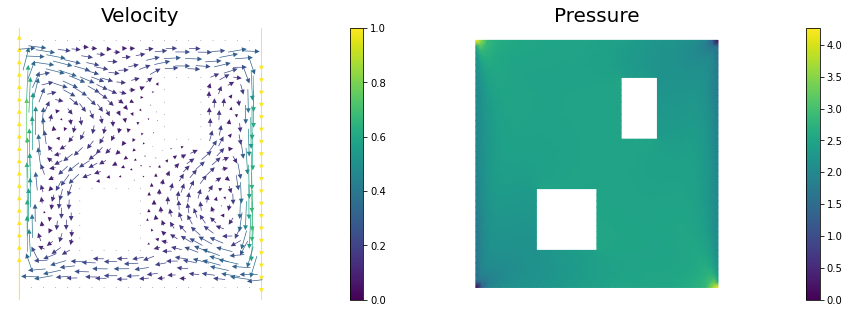

Number of dofs: 2023


In [3]:
mesh = dl.refine( dl.Mesh("ad_20.xml") )
wind_velocity = computeVelocityField(mesh)
Vh = dl.FunctionSpace(mesh, "Lagrange", 1)
print( "Number of dofs: {0}".format( Vh.dim() ) )

## 4. Set up true initial condition

In [4]:
ic_expr = dl.Expression(
    'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2) +  std::pow(x[1]-0.7,2))))',
    element=Vh.ufl_element())
true_initial_condition = dl.interpolate(ic_expr, Vh).vector()
    
t_init         = 0.
t_final        = 4.
t_1            = 1.
dt             = .1
observation_dt = .2
    
simulation_times = np.arange(t_init, t_final+.5*dt, dt)
observation_times = np.arange(t_1, t_final+.5*dt, observation_dt)
    
targets = np.loadtxt('targets.txt')
print ("Number of observation points: {0}".format(targets.shape[0]) )
# initialize observations
misfit = SpaceTimePointwiseStateObservation(Vh, observation_times, targets)

# objs = [dl.Function(Vh,true_initial_condition),
#         dl.Function(Vh,prior.mean)]
# mytitles = ["True Initial Condition", "Prior mean"]
# nb.multi1_plot(objs, mytitles)
# plt.show()

Number of observation points: 80


## 5. Generate the synthetic observations

In [5]:
# diffusivity
kappa_true = 0.001

# the code as written requires a prior to be passed in, but this should not be used in generating the observations
gamma = 1.
delta = 8.
# initialize prior w/ covariance C = (delta * I + gamma * Laplacian)^{-2}
prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
# constant mean
prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()

In [6]:
problem_true = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa_true, wind_velocity, True)
# relative noise level
#rel_noise = 0.01
rel_noise = 0.01

# initialize vector in the state space
utrue = problem_true.generate_vector(STATE)
x = [utrue, true_initial_condition, None]
# solve forward problem
problem_true.solveFwd(x[STATE], x)
# observe solution and add error
misfit.observe(x, misfit.d)
MAX = misfit.d.norm("linf", "linf")
noise_std_dev = rel_noise * MAX
parRandom.normal_perturb(noise_std_dev,misfit.d)

misfit.noise_variance = noise_std_dev*noise_std_dev

# plot solution
#nb.show_solution(Vh, true_initial_condition, utrue, "Solution")
#plt.savefig("forward_solution.pdf",pad_inches=1)

In [7]:
# Compare spectra of preconditioned vs unpreconditioned Hessian

# H = ReducedHessian(problem_true, misfit_only=True)
# k = 200
# p = 40
# Omega = MultiVector(x[PARAMETER], k+p)
# parRandom.normal(1., Omega)
# lmbda0, V0 = singlePassG(H, prior.R, prior.Rsolver, Omega, k)
# lmbda1, V1 = singlePass(H, Omega, k)

# plt.figure(figsize=(8,8))
# plt.rcParams.update({'font.size': 16})
# plt.semilogy(lmbda0,label='prior preconditioned')
# plt.semilogy(lmbda1,label='unpreconditioned')
# plt.ylabel('eigenvalue')
# plt.legend()

In [8]:
# initialize problem object
### added precon flag
def ComputePosterior(mesh, Vh, gamma, delta, misfit, simulation_times, kappa, wind_velocity, precon):
    prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
    prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    
    problem = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa, wind_velocity, True)
    
    ## Compute the gradient
    [u,m,p] = problem.generate_vector()
    # forward solve
    problem.solveFwd(u, [u,m,p])
    # adjoint solve
    problem.solveAdj(p, [u,m,p])
    # initialize a vector in the parameter space
    mg = problem.generate_vector(PARAMETER)
    # evaluate gradient and store in mg
    grad_norm = problem.evalGradientParameter([u,m,p], mg)
    
    ## Compute posterior precision
    # matrix free application of posterior precision/covariance
    H = ReducedHessian(problem, misfit_only=True)
    
    # finds eigenvalues/vectors of H*x = lambda*R*x
    #k = 120
    k = 200
    p = 40
    Omega = MultiVector(x[PARAMETER], k+p)
    parRandom.normal(1., Omega)
    if precon is True:
        lmbda, V = singlePassG(H, prior.R, prior.Rsolver, Omega, k)
    else:
        lmbda, V = singlePass(H, Omega, k)

    posterior = GaussianLRPosterior(prior, lmbda, V , precon)
    
    ## Compute posterior mean
    H.misfit_only = False
    solver = CGSolverSteihaug()
    solver.set_operator(H)
    solver.set_preconditioner( posterior.Hlr )
    solver.parameters["print_level"] = -1
    solver.parameters["rel_tolerance"] = 1e-6
    solver.solve(m, -mg)
    problem.solveFwd(u, [u,m,p])
    posterior.mean = m
    
    return posterior,mg,lmbda,V

In [9]:
# prior precision of kappa -- normal centered at -2, stdev = 3 (log values)
q_kappa = 1/3
# prior mean of kappa
mu_kappa = -2

# prior precision and mean of gamma and delta
q_g = 1/2
q_d = 1/2
mu_g = 5
mu_d = 5

In [10]:
# testing ComputePosterior

# posterior_precon = ComputePosterior(mesh, Vh, prior, misfit, simulation_times, kappa_true, wind_velocity, True)
# posterior_unprecon = ComputePosterior(mesh, Vh, prior, misfit, simulation_times, kappa_true, wind_velocity, False)

# b = Vector(x[PARAMETER])
# precision_precon = Vector(x[PARAMETER])
# precision_unprecon = Vector(x[PARAMETER])
# cov_precon = Vector(x[PARAMETER])
# cov_unprecon = Vector(x[PARAMETER])

# prior.init_vector(b,0)
# b[0] = 1

# posterior_precon.Hlr.mult(b,precision_precon)
# print('beginning of first column of posterior precision, preconditioned version:')
# print(precision_precon[0:9])

# posterior_unprecon.Hlr.mult(b,precision_unprecon)
# print('beginning of first column of posterior precision, unpreconditioned version:')
# print(precision_unprecon[0:9])


# posterior_precon.Hlr.solve(cov_precon, b)
# print('beginning of first column of posterior covariance, preconditioned version:')
# print(cov_precon[0:9])

# posterior_unprecon.Hlr.solve(cov_unprecon, b)
# print('beginning of first column of posterior covariance, unpreconditioned version:')
# print(cov_unprecon[0:9])

# # post_trace_p, pr_trace_p, corr_trace_p = posterior_precon.trace()
# # print('traces, preconditioned')
# # print(post_trace_p, pr_trace_p, corr_trace_p)

# # post_trace_u, pr_trace_u, corr_trace_u = posterior_unprecon.trace()
# # print('traces, unpreconditioned')
# # print(post_trace_u, pr_trace_u, corr_trace_u)

# post_point_var_p, pr_point_var_p, corr_point_var_p = posterior_precon.pointwise_variance(method="Exact")
# print('pointwise variances, preconditioned')
# print(post_point_var_p[0:9], pr_point_var_p[0:9], corr_point_var_p[0:9])

# post_point_var_u, pr_point_var_u, corr_point_var_u = posterior_unprecon.pointwise_variance(method="Exact")
# print('pointwise variances, unpreconditioned')
# print(post_point_var_u[0:9], pr_point_var_u[0:9], corr_point_var_u[0:9])

In [11]:
# -log pi(kappa | u_d) (- log posterior marginal pdf of kappa)
def neglogpi_kappa(kappa):
    # compute new posterior
    gamma = 1.
    delta = 8.
    posterior,mg,lmbda,V = ComputePosterior(mesh, Vh, gamma, delta, misfit, simulation_times, kappa, wind_velocity, True)
    # -log(|Q_u_0|/|Q_u_0^\ast|)
    det_ratio = 0.0
    for ll in posterior.d:
        det_ratio += np.log(1+ll)
    # -log pdf of kappa prior
    kappa_prior = 0.5*(q_kappa**2)*(np.log10(kappa)-mu_kappa)**2
    # u_0^\ast^T Q_u_0^\ast u_0^\ast
    #uQu = - 0.5*posterior.Hlr.inner(posterior.mean,posterior.mean) # does unnecessary work + introduces error
    uQu = 0.5*mg.inner(posterior.mean)
    return det_ratio + kappa_prior + uQu

# -log pi(gamma, delta | u_d) (- log posterior marginal joint pdf of gamma, delta)
def neglogpi_gamma_delta(gamma, delta):
    # compute new posterior
    kappa = 0.001
    posterior,mg,lmbda,V = ComputePosterior(mesh, Vh, gamma, delta, misfit, simulation_times, kappa, wind_velocity, False)
    # -log(|Q_u_0|/|Q_u_0^\ast|)
    # Bhelp = Q_u0^-1 * V
    Bhelp = MultiVector(V)
    for i in range(V.nvec()):
        posterior.prior.Rsolver.solve(Bhelp[i],V[i])
    # B = diag(lmbda) * V^T Q_u0^-1 V + I
    B = V.dot_mv(Bhelp)
    for i in range(B.shape[0]):
        B[i,:] *= lmbda[i]
        B[i,i] += 1.
    Bvals = np.linalg.eigvals(B)
    det_ratio = np.sum(np.log(Bvals))
    # -log pdf of gamma, delta prior
    gamma_delta_prior = 0.5*(q_g**2)*(gamma-mu_g)**2 + 0.5*(q_d**2)*(delta-mu_d)**2
    # u_0^\ast^T Q_u_0^\ast u_0^\ast
    #uQu = - 0.5*posterior.Hlr.inner(posterior.mean,posterior.mean) # does unnecessary work + introduces error
    uQu = 0.5*mg.inner(posterior.mean)
    return det_ratio + gamma_delta_prior + uQu, det_ratio, gamma_delta_prior, uQu

# plot -log pi for a range of kappas
g_range = np.linspace(1,60,5)
d_range = np.linspace(1,1000,5)
logpi = np.zeros((len(g_range),len(d_range)))
det_ratios = np.zeros((len(g_range),len(d_range)))
priors = np.zeros((len(g_range),len(d_range)))
uQus = np.zeros((len(g_range),len(d_range)))
for i in range(len(g_range)):
    for j in range(len(d_range)):
        logpi_ij,det_ij,pri_ij,uQu_ij = neglogpi_gamma_delta(g_range[i],d_range[j])
        logpi[i,j] = logpi_ij
        det_ratios[i,j] = det_ij
        priors[i,j] = pri_ij
        uQus[i,j] = uQu_ij
#det_ratios = np.array([0.0]*len(kap_range))
#kappa_priors = np.array([0.0]*len(kap_range))
#uQus = np.array([0.0]*len(kap_range))

# for idx in range(len(kap_range)):
#     print(f"Kappa iteration: {idx}")
#     logpi[idx] = neglogpi(kap_range[idx])

Text(0.5, 0, '$\\delta$')

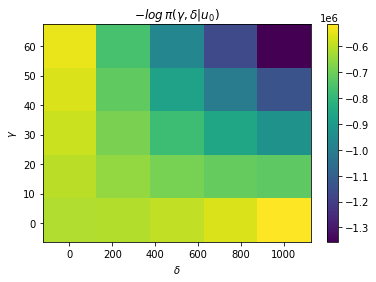

In [12]:
plt.pcolormesh(d_range,g_range,logpi)
plt.colorbar()
plt.title(r'$-log \, \pi(\gamma, \delta | u_d)$')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

Text(0.5, 0, '$\\delta$')

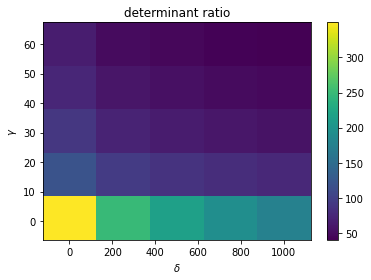

In [13]:
plt.pcolormesh(d_range,g_range,det_ratios)
plt.colorbar()
plt.title('determinant ratio')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

Text(0.5, 0, '$\\delta$')

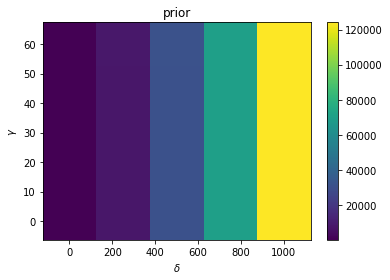

In [14]:
plt.pcolormesh(d_range,g_range,priors)
plt.colorbar()
plt.title('prior')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

Text(0.5, 0, '$\\delta$')

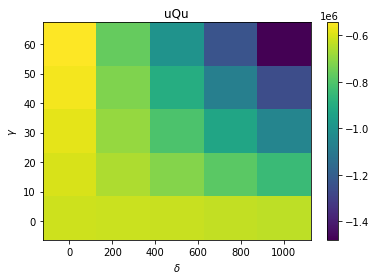

In [15]:
plt.pcolormesh(d_range,g_range,uQus)
plt.colorbar()
plt.title('uQu')
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

In [16]:
logpi

array([[ -615227.46708569,  -611814.39893915,  -593784.5977269 ,
         -561401.98521713,  -514868.98876675],
       [ -602730.71346024,  -651372.45066115,  -688697.85027528,
         -712734.87940131,  -723340.71180659],
       [ -582246.42567505,  -684019.72904504,  -777967.0611277 ,
         -859688.35081805,  -928729.21660653],
       [ -561612.10756188,  -718639.90710464,  -870424.58748808,
        -1010794.43237768, -1139063.02845922],
       [ -544034.52126627,  -757930.10799086,  -968275.17471049,
        -1167796.81154562, -1355656.83256697]])